In [1]:
import pandas as pd
import numpy as np

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

pd.set_option('display.max_columns', None)

### load data

In [2]:
df = pd.read_csv("../data/raw/applications.csv", low_memory=False)

print("Shape:", df.shape)
df.head()

Shape: (239664, 30)


,appid,name,type,is_free,release_date,required_age,short_description,supported_languages,header_image,background,metacritic_score,recommendations_total,mat_supports_windows,mat_supports_mac,mat_supports_linux,mat_initial_price,mat_final_price,mat_discount_percent,mat_currency,mat_achievement_count,mat_pc_os_min,mat_pc_processor_min,mat_pc_memory_min,mat_pc_graphics_min,mat_pc_os_rec,mat_pc_processor_rec,mat_pc_memory_rec,mat_pc_graphics_rec,created_at,updated_at
0,10,Counter-Strike,game,False,2000-11-01,0,Play the world's number 1 online action game. ...,"English<strong>*</strong>, French<strong>*</st...",https://shared.akamai.steamstatic.com/store_it...,https://store.akamai.steamstatic.com/images/st...,88.0,161854.0,True,True,True,999.0,999.0,0.0,USD,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2025-09-07 16:27:12.218587+00:00,2025-09-29 02:01:37.107239+00:00
1,20,Team Fortress Classic,game,False,1999-04-01,0,One of the most popular online action games of...,"English, French, German, Italian, Spanish - Sp...",https://shared.akamai.steamstatic.com/store_it...,https://store.akamai.steamstatic.com/images/st...,NaN,6633.0,True,True,True,499.0,499.0,0.0,USD,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2025-09-07 16:27:12.218587+00:00,2025-09-29 02:01:37.107239+00:00
2,30,Day of Defeat,game,False,2003-05-01,0,Enlist in an intense brand of Axis vs. Allied ...,"English, French, German, Italian, Spanish - Spain",https://shared.akamai.steamstatic.com/store_it...,https://store.akamai.steamstatic.com/images/st...,79.0,4308.0,True,True,True,499.0,499.0,0.0,USD,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2025-09-07 16:27:12.218587+00:00,2025-09-29 02:01:37.107239+00:00
3,40,Deathmatch Classic,game,False,2001-06-01,0,Enjoy fast-paced multiplayer gaming with Death...,"English, French, German, Italian, Spanish - Sp...",https://shared.akamai.steamstatic.com/store_it...,https://store.akamai.steamstatic.com/images/st...,NaN,2338.0,True,True,True,499.0,499.0,0.0,USD,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2025-09-07 16:27:12.218587+00:00,2025-09-29 02:01:37.107239+00:00
4,50,Half-Life: Opposing Force,game,False,1999-11-01,0,Return to the Black Mesa Research Facility as ...,"English, French, German, Korean",https://shared.akamai.steamstatic.com/store_it...,https://store.akamai.steamstatic.com/images/st...,NaN,22793.0,True,True,True,499.0,499.0,0.0,USD,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2025-09-07 16:27:12.218587+00:00,2025-09-29 02:01:37.107239+00:00


### copy data để xử lý

In [3]:
df_clean = df.copy()

### 1. xử lý missing values

- drop những cột thiếu quá nhiều (>70%)

In [4]:
missing_percent = df_clean.isnull().mean() * 100

cols_to_drop = missing_percent[missing_percent > 70].index
print("Columns to drop:", cols_to_drop)

df_clean.drop(columns=cols_to_drop, inplace=True)

Columns to drop: Index(['metacritic_score', 'recommendations_total', 'mat_achievement_count'], dtype='str')


- check lại

In [5]:
df_clean.shape

(239664, 27)

- xử lý missing cho các cột quan trọng

In [9]:
# Xử lý giá trị thiếu (null) cho dataframe
df_clean = df_clean.fillna({
    # price → fill 0
    'mat_final_price': 0,
    'mat_initial_price': 0,
    'mat_discount_percent': 0,
    
    # text → fill unknown
    'type': 'unknown',
    'supported_languages': 'unknown'
})

# release_date → giữ lại (xử lý sau)

### 2. Chuyển đổi Data type

- Convert required_age

In [13]:
# chuyển sang kiểu số, các giá trị lỗi sẽ thành NaN
df_clean['required_age'] = pd.to_numeric(df_clean['required_age'], errors='coerce')

# điền 0 vào các vị trí NaN và gán ngược lại vào cột
df_clean['required_age'] = df_clean['required_age'].fillna(0)

- Convert release_date

In [14]:
# chuyển đổi sang datetime
df_clean['release_date'] = pd.to_datetime(df_clean['release_date'], errors='coerce')

# tạo feature mới và xử lý luôn giá trị null
df_clean['release_year'] = df_clean['release_date'].dt.year.fillna(0).astype(int)
df_clean['release_month'] = df_clean['release_date'].dt.month.fillna(0).astype(int)

### 3. Feature Engineering

- Feature: has_discount

In [15]:
df_clean['has_discount'] = df_clean['mat_discount_percent'] > 0

- Feature: price_category

In [16]:
def price_category(price):
    if price == 0:
        return 'free'
    elif price < 10:
        return 'cheap'
    elif price < 30:
        return 'medium'
    else:
        return 'expensive'

df_clean['price_category'] = df_clean['mat_final_price'].apply(price_category)

- Feature: platform_count

In [17]:
df_clean['platform_count'] = (
    df_clean['mat_supports_windows'].astype(int) +
    df_clean['mat_supports_mac'].astype(int) +
    df_clean['mat_supports_linux'].astype(int)
)

### 4. Loại cột không cần thiết

- Drop cột không dùng

In [18]:
cols_drop = [
    'name',
    'short_description',
    'header_image',
    'background',
    'release_date',
    'created_at',
    'updated_at'
]

df_clean.drop(columns=cols_drop, inplace=True, errors='ignore')

### 5. Encode Data

- One-hot encoding

In [19]:
df_encoded = pd.get_dummies(df_clean, columns=['type', 'price_category'], drop_first=True)

### 6. Chuẩn hóa (Scaling)

- Chọn numeric columns

In [20]:
numeric_cols = df_encoded.select_dtypes(include=['int64', 'float64']).columns

- Scale dữ liệu

In [21]:
scaler = StandardScaler()

df_encoded[numeric_cols] = scaler.fit_transform(df_encoded[numeric_cols])

- Xử lý supported_languages
    - trích xuất số lượng ngôn ngữ

In [24]:
import re

def count_languages(text):
    if pd.isna(text):
        return 0
    # bỏ HTML tags
    clean_text = re.sub('<.*?>', '', text)
    # split theo dấu phẩy
    langs = clean_text.split(',')
    return len(langs)

df_clean['num_languages'] = df_clean['supported_languages'].apply(count_languages)

- loại bỏ toàn bộ cột text

In [26]:
df_pca_input = df_clean.select_dtypes(include=['int64', 'float64', 'bool']).copy()

- Convert bool → int

In [27]:
df_pca_input = df_pca_input.astype(float)

- Fill missing

In [28]:
df_pca_input = df_pca_input.fillna(0)

- Scaling

In [29]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_pca_input)

### 7. PCA

- Áp dụng PCA

In [30]:
from sklearn.decomposition import PCA

pca = PCA(n_components=0.95)
X_pca = pca.fit_transform(X_scaled)

print("Before PCA:", X_scaled.shape)
print("After PCA:", X_pca.shape)

Before PCA: (239664, 14)
After PCA: (239664, 9)


- Explained variance

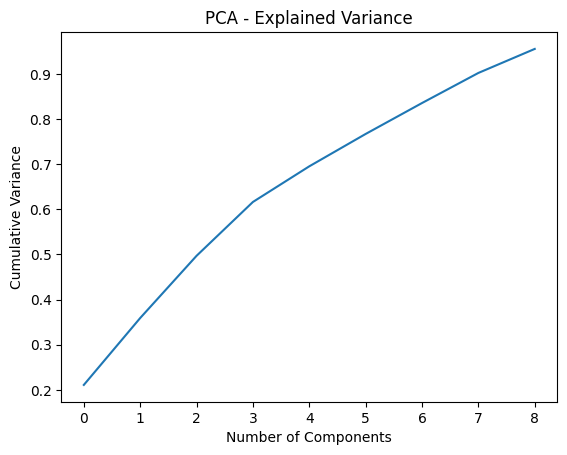

In [31]:
import numpy as np
import matplotlib.pyplot as plt

plt.plot(np.cumsum(pca.explained_variance_ratio_))
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Variance")
plt.title("PCA - Explained Variance")
plt.show()

Sau khi áp dụng PCA với ngưỡng giữ lại 95% phương sai, số chiều dữ liệu đã giảm đáng kể. Điều này giúp mô hình học nhanh hơn, giảm overfitting và loại bỏ sự dư thừa giữa các biến.

In [32]:
X_pca

array([[-0.0321448 ,  0.74694337, -0.03481015, ...,  0.09115316,
        -0.87053898, -0.74274553],
       [ 0.01187564,  0.23487471, -0.01376133, ...,  0.06523549,
        -0.68666031, -1.38062793],
       [ 0.00597572,  0.26599517, -0.01354946, ...,  0.056832  ,
        -0.56353241, -1.19322682],
       ...,
       [ 0.23160506, -2.14025657,  0.07490638, ..., -0.17469767,
         1.49636768, -0.29030074],
       [ 0.1085173 , -0.58452204,  0.00973445, ..., -0.12658472,
         1.12792187,  0.86388545],
       [ 0.10867097, -0.59603079,  0.01063419, ..., -0.12973252,
         1.16676776,  0.8892662 ]], shape=(239664, 9))

## Kết luận

#### 1. Xử lý missing values
* Loại bỏ các cột thiếu >70%
* Fill các cột giá bằng 0
* Fill categorical bằng "unknown"

#### 2. Chuyển đổi dữ liệu
* `required_age` → numeric
* `release_date` → datetime → tạo year, month

#### 3. Feature Engineering
Tạo thêm các feature:
* `has_discount`
* `price_category`
* `platform_count`

#### 4. Encoding
One-hot encoding cho:
* `type`
* `price_category`

#### 5. Scaling
* Chuẩn hóa toàn bộ numeric features bằng StandardScaler

#### 6. PCA
Giảm chiều dữ liệu:
* Giữ lại 95% thông tin
* Giúp:
    * giảm nhiễu
    * tăng tốc model

#### 7. Kết quả
Data đã sạch, sẵn sàng cho:
* Regression
* Classification
* Clustering

In [33]:
# Save clean data
df_clean.to_csv("../data/processed/clean_data.csv", index=False)

# Save PCA
pd.DataFrame(X_pca).to_csv("../data/processed/pca_data.csv", index=False)